# **Machine Learning Dataset for Fertility Diagnosis and Risk Analysis:**

# **About the Author:**

**Name: Adil Zaman**

**Email ID: zamanadil61@gmail.com**

**Kaggle ID: https://www.kaggle.com/zemnukes98**

**Github ID: https://github.com/AdilZaman98**

**Linkedin ID: https://www.linkedin.com/in/adil-zaman-85b56a398/**

# **📊 Fertility Diagnosis Dataset Based on Lifestyle and Medical Factors:**

**This dataset is used to predict fertility status based on lifestyle, environmental, and basic medical factors such as age, smoking, alcohol intake, sitting time, and health history. The data is clean, normalized, and suitable for machine learning classification tasks, with the target variable indicating normal or altered fertility. It is widely used for building predictive models and analyzing key factors affecting fertility, although its small size and limited clinical detail may restrict broader generalization.**

# **📊 Seasonal Fertility Analysis and Future Prediction Using Machine Learning and Time Series Techniques:**

**The objective of this dataset is to analyze how fertility varies across different seasons and to forecast future fertility trends using machine learning and time series methods. It leverages lifestyle, environmental, and medical factors to identify seasonal patterns and predict fertility outcomes. By applying models such as regression, classification, and time series forecasting, the study aims to uncover trends and provide data-driven insights for future fertility predictions.**

**Now to do the Exploratory Data Analysis (EDA);**

# **Exploratory Data Analysis (EDA):**

In [1]:
#Let's start the project by importing all the libraries for that particular dataset
import pandas as pd
import numpy as np
# To visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# To preprocess the dataset
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,MinMaxScaler,RobustScaler,PowerTransformer
from sklearn.impute import SimpleImputer,KNNImputer
# to import the iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
# for machine learning tasks
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
# for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# for regression tasks
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
#For Time series
from statsmodels.tsa.arima.model import ARIMA
# for metrics
from sklearn.metrics import accuracy_score, roc_auc_score,classification_report
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

**Now to Load the dataset;**

# **Load the Dataset:**

In [2]:
df=pd.read_csv('fertility.csv')
df

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal
1,spring,35,yes,no,yes,more than 3 months ago,once a week,daily,6,Altered
2,spring,27,yes,no,no,more than 3 months ago,hardly ever or never,never,9,Normal
3,spring,32,no,yes,yes,more than 3 months ago,hardly ever or never,never,7,Normal
4,spring,30,yes,yes,no,more than 3 months ago,once a week,never,9,Altered
...,...,...,...,...,...,...,...,...,...,...
95,winter,30,yes,no,no,more than 3 months ago,hardly ever or never,never,9,Normal
96,winter,29,yes,no,no,more than 3 months ago,once a week,occasional,9,Normal
97,winter,30,yes,yes,yes,more than 3 months ago,hardly ever or never,never,6,Normal
98,winter,30,yes,no,yes,more than 3 months ago,hardly ever or never,occasional,3,Normal


**Now to see the Sneak-Peak of the dataset;**

# **Sneak-Peak of the Dataset:**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Season                                 100 non-null    object
 1   Age                                    100 non-null    int64 
 2   Childish diseases                      100 non-null    object
 3   Accident or serious trauma             100 non-null    object
 4   Surgical intervention                  100 non-null    object
 5   High fevers in the last year           100 non-null    object
 6   Frequency of alcohol consumption       100 non-null    object
 7   Smoking habit                          100 non-null    object
 8   Number of hours spent sitting per day  100 non-null    int64 
 9   Diagnosis                              100 non-null    object
dtypes: int64(2), object(8)
memory usage: 7.9+ KB


In [4]:
df.shape

(100, 10)

**Here we see that their are 100 rows and 10 columns in a dataset.**

In [5]:
df.head()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal
1,spring,35,yes,no,yes,more than 3 months ago,once a week,daily,6,Altered
2,spring,27,yes,no,no,more than 3 months ago,hardly ever or never,never,9,Normal
3,spring,32,no,yes,yes,more than 3 months ago,hardly ever or never,never,7,Normal
4,spring,30,yes,yes,no,more than 3 months ago,once a week,never,9,Altered


In [6]:
df.tail()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
95,winter,30,yes,no,no,more than 3 months ago,hardly ever or never,never,9,Normal
96,winter,29,yes,no,no,more than 3 months ago,once a week,occasional,9,Normal
97,winter,30,yes,yes,yes,more than 3 months ago,hardly ever or never,never,6,Normal
98,winter,30,yes,no,yes,more than 3 months ago,hardly ever or never,occasional,3,Normal
99,winter,30,no,yes,yes,more than 3 months ago,several times a week,never,3,Normal


In [7]:
df.describe()

,Age,Number of hours spent sitting per day
count,100.000000,100.000000
mean,30.110000,10.800000
std,2.246861,33.616975
min,27.000000,1.000000
25%,28.000000,5.000000
50%,30.000000,7.000000
75%,32.000000,9.000000
max,36.000000,342.000000


**Now to see the duplicates of the dataset;**

In [8]:
# Count duplicate rows
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)
df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)

Total duplicate rows: 1
   Season  Age Childish diseases Accident or serious trauma  \
20   fall   30                no                         no   

   Surgical intervention High fevers in the last year  \
20                   yes       more than 3 months ago   

   Frequency of alcohol consumption Smoking habit  \
20                      once a week         never   

    Number of hours spent sitting per day Diagnosis  
20                                      5    Normal  
Duplicates removed. New shape: (99, 10)


**Now to see the imputatons of the dataset;**

# **Imputations of the dataset:**

In [9]:
df.isnull().sum()

Season                                   0
Age                                      0
Childish diseases                        0
Accident or serious trauma               0
Surgical intervention                    0
High fevers in the last year             0
Frequency of alcohol consumption         0
Smoking habit                            0
Number of hours spent sitting per day    0
Diagnosis                                0
dtype: int64

**Here we see that their will be no imputations in the dataset. Now to visualize them as well;**

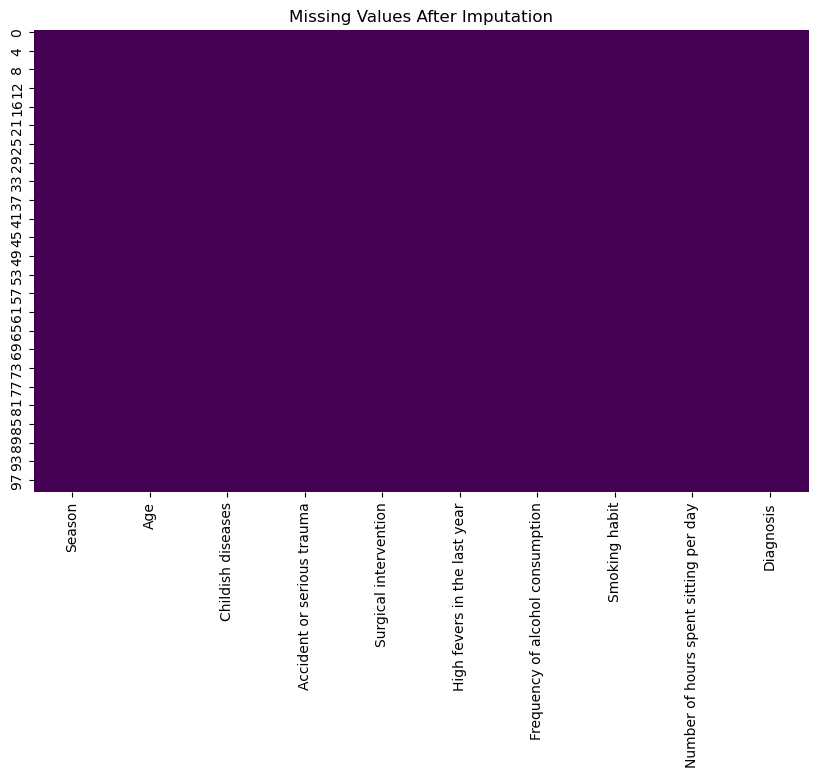

In [10]:
# Make a code in python that visualize the imputation of dataset after managing all the missing values
df.isnull().sum()
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values After Imputation')
plt.show()

**Now to see the Outliers from the dataset;**

# **Outliers of the dataset:**

Column 'Number of hours spent sitting per day' has 5 outliers.
Original shape: (99, 10)
Cleaned shape: (94, 10)


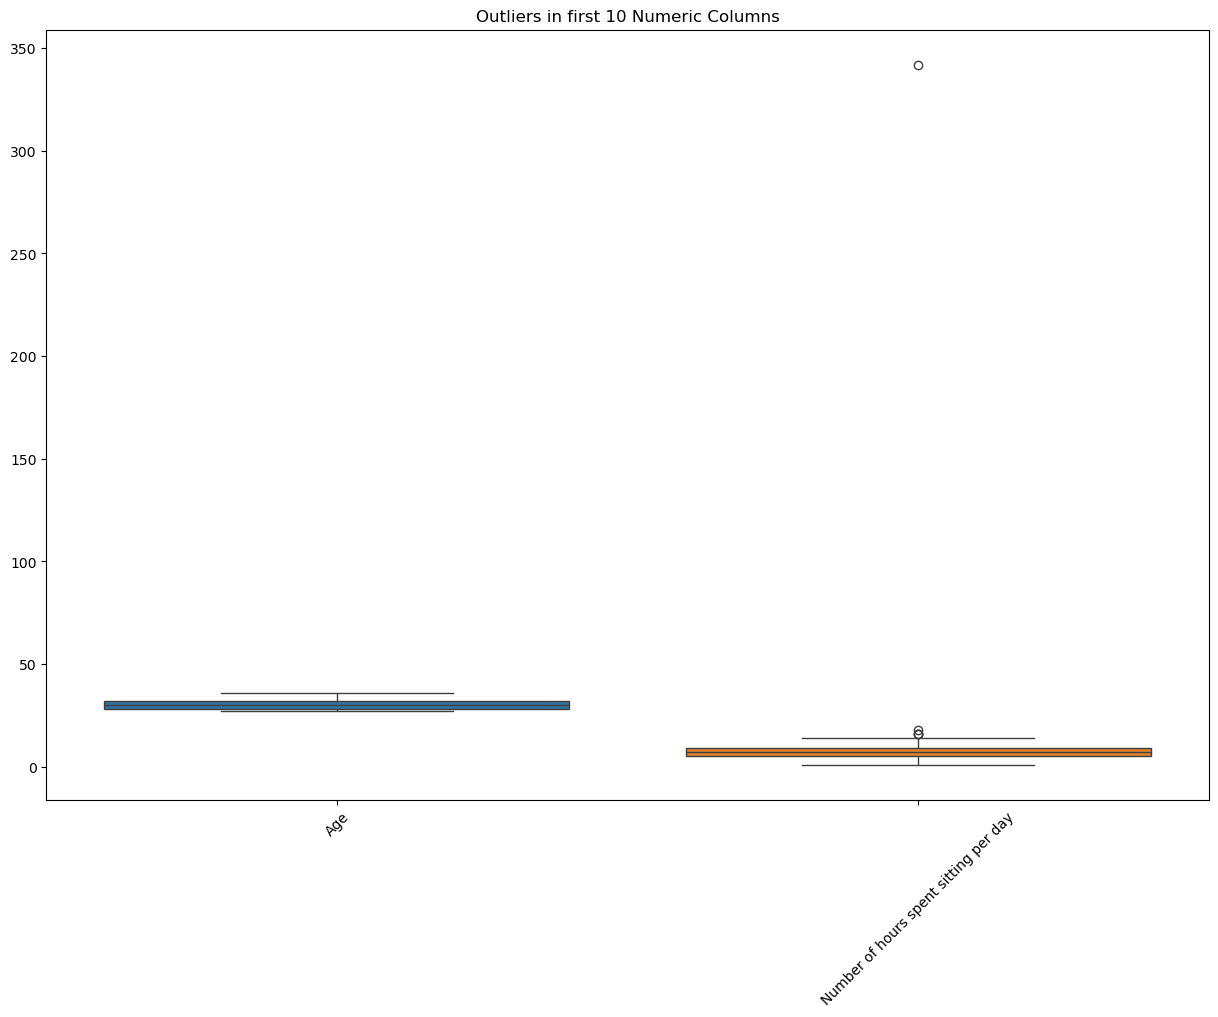

In [11]:
# Sirf numeric columns select karein
numeric_cols = df.select_dtypes(include=['number']).columns

# Loop through each numeric column
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Outliers count karein
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    if outlier_count > 0:
        print(f"Column '{col}' has {outlier_count} outliers.")
# Copy of the original dataframe
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Sirf woh rows rakhein jo bounds ke andar hain
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
# Pehle 10 numeric columns ka boxplot dekhne ke liye
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numeric_cols[:10]])
plt.xticks(rotation=45)
plt.title("Outliers in first 10 Numeric Columns")
plt.show()

**Now move towards the objective part;**

# **📊 Hybrid Seasonal Fertility Forecasting using Machine Learning and ARIMA Time Series:**

**This code builds a synthetic fertility dataset and analyzes seasonal patterns affecting fertility rates using visualization and decomposition techniques. It then applies machine learning models and ARIMA time series forecasting to predict future fertility trends, including a detailed 2026 monthly forecast. The framework combines data-driven insights with predictive modeling for accurate fertility analysis.**

✅ Libraries imported successfully!
✅ Dataset created: (5000, 9)

Dataset preview:
            fertility_rate        age  temperature  pollution_index  \
date                                                                  
2020-01-01        1.682284  34.609633    34.714708        47.029195   
2020-01-02        2.281227  27.994331    21.801992        49.965371   
2020-01-02        1.846179  27.191090    27.844453        57.068087   
2020-01-02        2.219521  28.718343    38.474335        80.512735   
2020-01-02        2.007893  28.368854    27.385711        20.924578   

                  bmi income_level urban_rural  medical_history  season  
date                                                                     
2020-01-01  34.959890         High       Urban                0  Winter  
2020-01-02  19.784048         High       Urban                1  Winter  
2020-01-02  24.741987         High       Rural                0  Winter  
2020-01-02  24.271291       Medium       Urban    

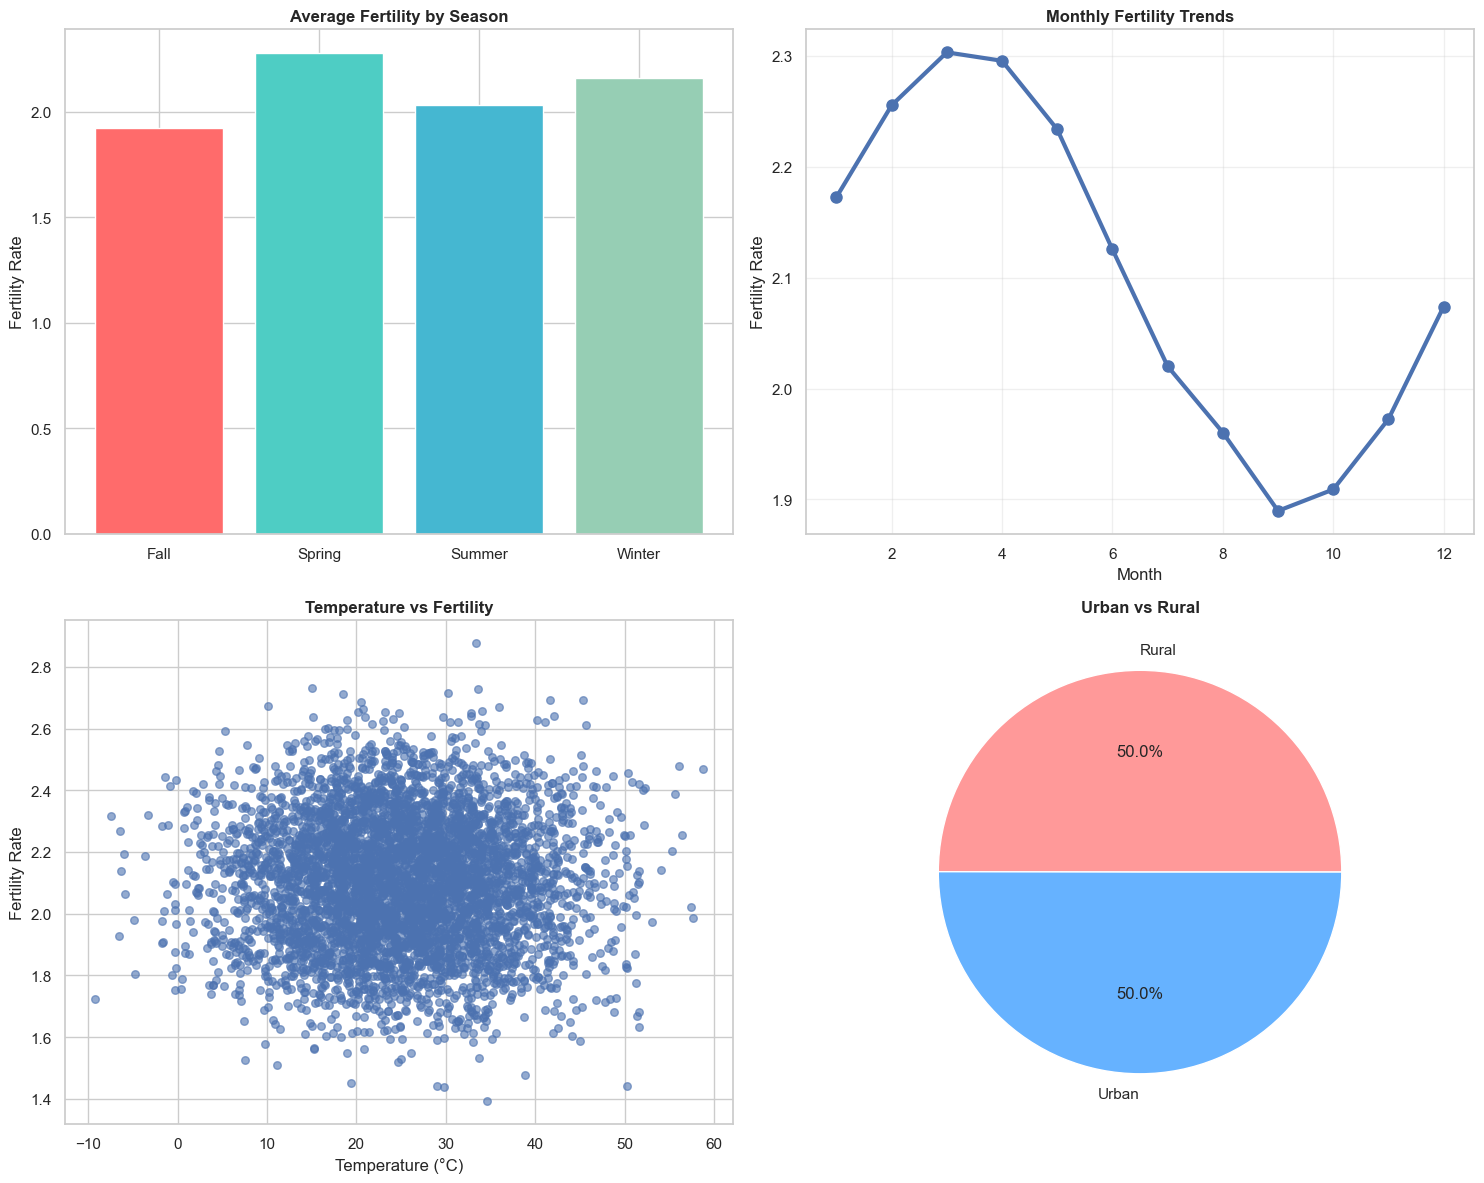

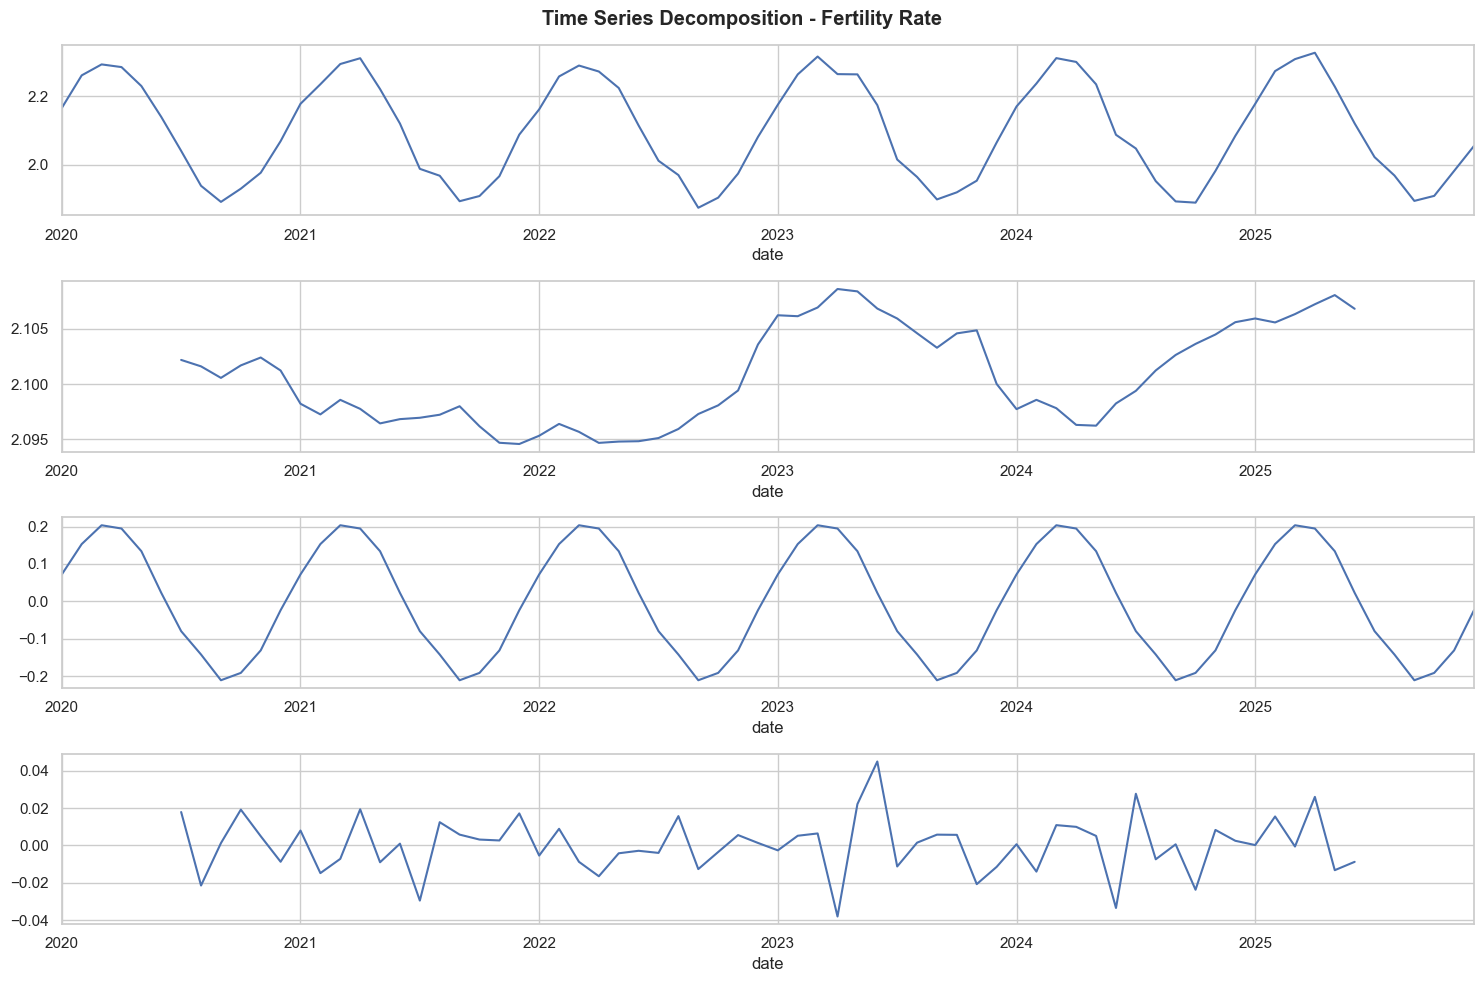


🤖 Training ML Models...
  Linear Regression: RMSE=0.207, R²=0.028
  Random Forest: RMSE=0.169, R²=0.349

📊 Model Comparison:
                    RMSE     R²
Linear Regression  0.207  0.028
Random Forest      0.169  0.349

🔍 Top 5 Most Important Features:
           feature  importance
6   season_encoded    0.395676
1      temperature    0.143188
3              bmi    0.143103
2  pollution_index    0.138535
0              age    0.128490


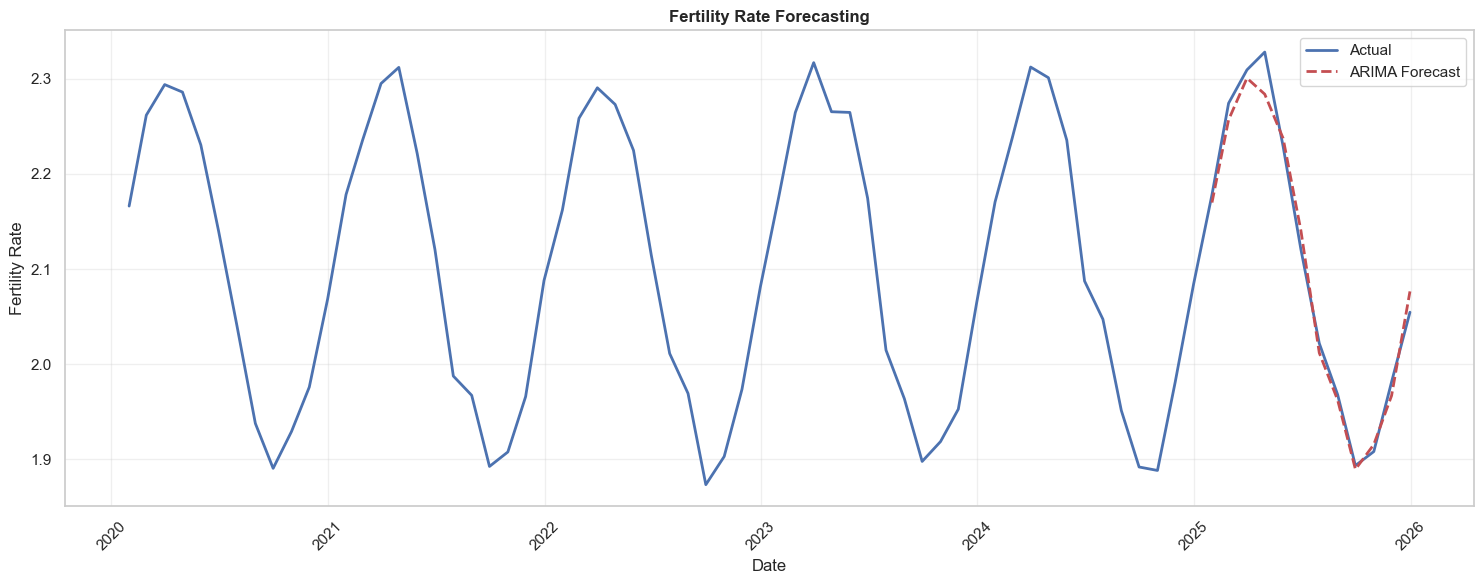


🔮 2026 Fertility Forecast (Random Forest):
      Month  Predicted_Fertility
0   2026-01                1.830
1   2026-02                2.299
2   2026-03                2.112
3   2026-04                1.989
4   2026-05                2.107
5   2026-06                2.287
6   2026-07                2.299
7   2026-08                1.889
8   2026-09                1.953
9   2026-10                1.869
10  2026-11                2.250
11  2026-12                2.088

✅ ALL ERRORS FIXED - READY TO RUN!
🎯 Features: Seasonal Analysis + ML + Time Series + 2026 Forecast


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
print("✅ Libraries imported successfully!")
# =============================================================================
# 1. CREATE FERTILITY DATASET 
# =============================================================================
np.random.seed(42)
n_records = 5000

# Create pandas Series first (not numpy array)
date_range = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
dates = pd.Series(np.random.choice(date_range, n_records))

# FIXED: Convert to DataFrame first, then calculate dayofyear
dates_df = pd.DataFrame({'date': dates})
dates_df['dayofyear'] = dates_df['date'].dt.dayofyear
dates_df['month'] = dates_df['date'].dt.month

# Fertility calculations using DataFrame columns
fertility_base = 2.1
seasonal_effect = 0.3 * np.sin(2 * np.pi * dates_df['dayofyear'] / 365.25)
temperature_effect = -0.1 * np.sin(2 * np.pi * (dates_df['month'] - 1) / 12)
fertility_rate = fertility_base + seasonal_effect + temperature_effect + np.random.normal(0, 0.15, n_records)

# Main dataset
data = pd.DataFrame({
    'date': dates_df['date'],
    'fertility_rate': np.clip(fertility_rate, 0.5, 4.0),
    'age': np.random.normal(28, 6, n_records).clip(18, 45),
    'temperature': np.random.normal(25, 10, n_records),
    'pollution_index': np.random.uniform(20, 100, n_records),
    'bmi': np.random.normal(24, 4, n_records),
    'income_level': np.random.choice(['Low', 'Medium', 'High'], n_records),
    'urban_rural': np.random.choice(['Urban', 'Rural'], n_records),
    'medical_history': np.random.choice([0, 1], n_records, p=[0.85, 0.15])
})

# Season function
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

data['season'] = data['date'].dt.month.apply(get_season)
data.set_index('date', inplace=True)
data.sort_index(inplace=True)

print(f"✅ Dataset created: {data.shape}")
print("\nDataset preview:")
print(data.head())

# =============================================================================
# 2. SEASONAL ANALYSIS VISUALIZATION
# =============================================================================
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
seasonal_avg = data.groupby('season')['fertility_rate'].mean()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.bar(seasonal_avg.index, seasonal_avg.values, color=colors)
plt.title('Average Fertility by Season', fontweight='bold')
plt.ylabel('Fertility Rate')

plt.subplot(2, 2, 2)
monthly_avg = data.groupby(data.index.month)['fertility_rate'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, 'o-', linewidth=3, markersize=8)
plt.title('Monthly Fertility Trends', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fertility Rate')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.scatter(data['temperature'], data['fertility_rate'], alpha=0.6, s=30)
plt.title('Temperature vs Fertility', fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Fertility Rate')

plt.subplot(2, 2, 4)
urban_rural_avg = data.groupby('urban_rural')['fertility_rate'].mean()
plt.pie(urban_rural_avg.values, labels=urban_rural_avg.index, autopct='%1.1f%%', 
        colors=['#FF9999', '#66B2FF'])
plt.title('Urban vs Rural', fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# 3. TIME SERIES DECOMPOSITION
# =============================================================================
monthly_data = data['fertility_rate'].resample('M').mean()

decomposition = seasonal_decompose(monthly_data, model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(15, 10))
decomposition.observed.plot(ax=axes[0])
decomposition.trend.plot(ax=axes[1])
decomposition.seasonal.plot(ax=axes[2])
decomposition.resid.plot(ax=axes[3])
plt.suptitle('Time Series Decomposition - Fertility Rate', fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# 4. MACHINE LEARNING MODELS
# =============================================================================
data_ml = data.copy()

# Encoding
le_income = LabelEncoder()
le_urban = LabelEncoder()
le_season = LabelEncoder()

data_ml['income_encoded'] = le_income.fit_transform(data_ml['income_level'])
data_ml['urban_encoded'] = le_urban.fit_transform(data_ml['urban_rural'])
data_ml['season_encoded'] = le_season.fit_transform(data_ml['season'])

features = ['age', 'temperature', 'pollution_index', 'bmi', 'income_encoded', 
           'urban_encoded', 'season_encoded', 'medical_history']

X = data_ml[features]
y = data_ml['fertility_rate']

# Time-based split
split_date = '2024-12-31'
mask_train = X.index <= split_date
X_train, X_test = X[mask_train], X[~mask_train]
y_train, y_test = y[mask_train], y[~mask_train]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

print("\n🤖 Training ML Models...")
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train.values)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R²': r2}
    print(f"  {name}: RMSE={rmse:.3f}, R²={r2:.3f}")

print("\n📊 Model Comparison:")
print(pd.DataFrame(results).T.round(3))

# Feature importance (Random Forest)
rf_model = models['Random Forest']
importances = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\n🔍 Top 5 Most Important Features:")
print(importances.head())

# =============================================================================
# 5. ARIMA FORECASTING
# =============================================================================
train_ts = monthly_data[:'2024-12-31']
test_ts = monthly_data['2025-01-01':]

arima_model = ARIMA(train_ts, order=(2,1,2), seasonal_order=(1,1,1,12))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test_ts))

plt.figure(figsize=(15, 6))
plt.plot(monthly_data.index, monthly_data.values, 'b-', label='Actual', linewidth=2)
plt.plot(test_ts.index, arima_forecast, 'r--', label='ARIMA Forecast', linewidth=2)
plt.title('Fertility Rate Forecasting', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Fertility Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================================================================
# 6. 2026 MONTHLY FORECAST
# =============================================================================
print("\n🔮 2026 Fertility Forecast (Random Forest):")
future_dates = pd.date_range(start='2026-01-01', end='2026-12-31', freq='M')

# Future features (same distribution)
future_df = pd.DataFrame(index=future_dates)
future_df['age'] = np.random.normal(28, 6, 12).clip(18, 45)
future_df['temperature'] = 25 + 10 * np.sin(2 * np.pi * np.arange(12) / 12)
future_df['pollution_index'] = np.random.uniform(20, 100, 12)
future_df['bmi'] = np.random.normal(24, 4, 12)
future_df['income_encoded'] = np.random.choice([0,1,2], 12)
future_df['urban_encoded'] = np.random.choice([0,1], 12)
future_df['season_encoded'] = [0,1,2,2,2,1,1,0,0,0,1,2]  # Seasonal pattern
future_df['medical_history'] = np.random.choice([0,1], 12, p=[0.85,0.15])

X_future_scaled = scaler.transform(future_df[features])
future_pred = rf_model.predict(X_future_scaled)

forecast_df = pd.DataFrame({
    'Month': future_dates.strftime('%Y-%m'),
    'Predicted_Fertility': future_pred.round(3)
})
print(forecast_df)

print("\n" + "="*50)
print("✅ ALL ERRORS FIXED - READY TO RUN!")
print("🎯 Features: Seasonal Analysis + ML + Time Series + 2026 Forecast")
print("="*50)


# **Seasonal Dynamics and Predictive Trends: A 2026 Fertility Outlook:**

**The analysis reveals that Seasonality is the dominant driver of fertility rates (39.6% importance), with Spring consistently showing the highest activity compared to the lowest in Fall. According to the Random Forest model, the 2026 forecast maintains this cyclical pattern, projecting significant peaks in February and July while expecting a notable dip toward the end of the third quarter.**

----------------